Evaluación de Fundamentos de NLP - Caso Fisioterapia
En este notebook se ponen en práctica conceptos de procesamiento de lenguaje natural aplicados a un texto técnico de salud, siguiendo los requerimientos de la actividad.

Objetivos:
-Cargar un corpus externo (resumen_fisioterapia.txt).
-Analizar la estructura gramatical (POS Tagging).
-Visualizar la distribución de categorías gramaticales.

In [1]:
import spacy
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el modelo en español configurado previamente
nlp = spacy.load('es_core_news_sm')

1. Carga del documento externo
A diferencia del ejemplo guía, utilizamos un texto sobre crioterapia y rehabilitación.

In [2]:
with open('resumen_fisioterapia.txt', 'r', encoding='utf-8') as f:
    texto = f.read()

doc = nlp(texto)
print(f"Documento cargado. Total de tokens: {len(doc)}")

Documento cargado. Total de tokens: 55


2. Análisis de tokens y lemas
Extraemos la información lingüística de las primeras oraciones del texto.

In [3]:
print("{:20}{:20}{:20}".format("Texto", "POS Tag", "Lema"))
print("-" * 60)
for token in list(doc)[:15]:
    if not token.is_space:
        print(f"{token.text:{20}}{token.pos_:{20}}{token.lemma_:{20}}")

Texto               POS Tag             Lema                
------------------------------------------------------------
La                  DET                 el                  
crioterapia         NOUN                crioterapia         
es                  AUX                 ser                 
una                 DET                 uno                 
técnica             NOUN                técnica             
de                  ADP                 de                  
fisioterapia        NOUN                fisioterapia        
basada              ADJ                 basado              
en                  ADP                 en                  
la                  DET                 el                  
aplicación          NOUN                aplicación          
de                  ADP                 de                  
frío                NOUN                frío                
sobre               ADP                 sobre               
el                  DET 

Es interesante observar la proporción de sustantivos frente a verbos, lo cual define qué tan descriptivo es el lenguaje técnico utilizado.

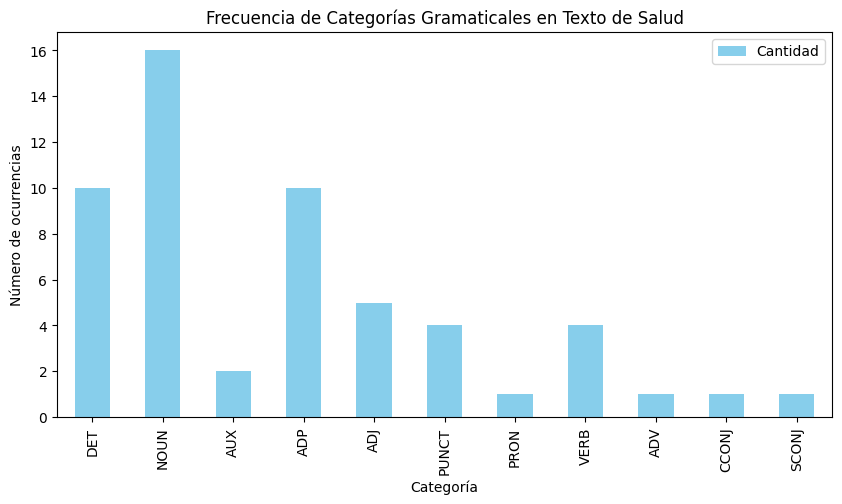

In [4]:
# Conteo de categorías gramaticales
pos_counts = doc.count_by(spacy.attrs.POS)
df_pos = pd.DataFrame([{"Categoría": doc.vocab[k].text, "Cantidad": v} for k, v in pos_counts.items()])

# Visualización con gráfico de barras
df_pos.plot(kind='bar', x='Categoría', y='Cantidad', color='skyblue', figsize=(10,5))
plt.title("Frecuencia de Categorías Gramaticales en Texto de Salud")
plt.ylabel("Número de ocurrencias")
plt.show()